In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv('../data/clean_dataset.csv')

data = np.array(df).reshape((df.shape[0], df.shape[1], 1))

In [3]:
import pickle

def normalizeData(data) :
  scaler = MinMaxScaler(feature_range=(0,1))
  data_scaled = np.zeros((data.shape[0], data.shape[1], 1))
  
  for i in range(data.shape[1]) :
    data_scaled[:,i] = scaler.fit_transform(data[:,i])
    
    with open(f'../scalers/scaler_{i+1}.pkl', 'wb') as file:
      pickle.dump(scaler, file)
  
  return data_scaled

data_scaled = normalizeData(data)

In [4]:
train_split = round(len(data_scaled)*0.80) 
test_split = round(len(data_scaled)*0.10)

data_train = data_scaled[:train_split]
data_val = data_scaled[train_split:-test_split]
data_test = data_scaled[-test_split:]

In [25]:
n_feature = 8
n_timestep = 30
n_output = 31

def createXY(data, n_timestep, n_feature):
  dataX = []
  dataY = []
  for i in range(n_timestep, len(data) - n_output):
    dataX.append(data[i-n_timestep : i, n_feature])
    dataY.append(data[i : i+n_output, n_feature])
  dataX = np.array(dataX)
  dataY = np.array(dataY)
  dataY = dataY.reshape(dataY.shape[0], dataY.shape[1])
  return dataX, dataY

trainX, trainY = createXY(data_train, n_timestep, n_feature)
testX, testY = createXY(data_test, n_timestep, n_feature)
valX, valY = createXY(data_val, n_timestep, n_feature)

input_shape = trainX[0].shape

In [39]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Input(shape=input_shape),
  tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(units=64, return_sequences=True)),
  tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(units=64)),
  tf.keras.layers.Dense(units=n_output),
])
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
              loss='mean_squared_error')

history = model.fit(trainX, trainY, 
                    epochs=30, 
                    batch_size=16, 
                    validation_data=(valX, valY), 
                    verbose=1,)

Epoch 1/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - loss: 0.1724 - val_loss: 0.0550
Epoch 2/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.1661 - val_loss: 0.0510
Epoch 3/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.1467 - val_loss: 0.0465
Epoch 4/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.1361 - val_loss: 0.0410
Epoch 5/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.1278 - val_loss: 0.0340
Epoch 6/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.1044 - val_loss: 0.0258
Epoch 7/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0856 - val_loss: 0.0172
Epoch 8/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0668 - val_loss: 0.0102
Epoch 9/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0435 - val_loss: 0.0061
Epoch 10/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0326 - val_loss: 0.0039
Epoch 11/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0256 - val_loss: 0.0025
Epoch 12/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.

In [40]:
if __name__ == '__main__':
    model.save(f"../models/model_{n_feature+1}.h5")

In [22]:
# Memuat scaler dari file .pkl
with open('../scalers/scaler_9.pkl', 'rb') as file:
    scaler = pickle.load(file)

In [23]:
# Memuat model dari file .h5
model = tf.keras.models.load_model('../models/model_9.h5')

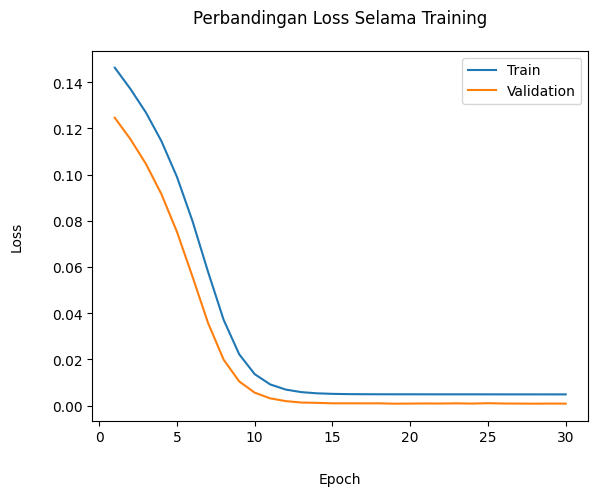

In [708]:
epochs_range = range(1, len(history.history['loss']) + 1)
plt.plot(epochs_range, history.history['loss'])
plt.plot(epochs_range, history.history['val_loss'])
plt.title('Perbandingan Loss Selama Training', pad=20)
plt.xlabel('Epoch', labelpad=20)
plt.ylabel('Loss', labelpad=20)
plt.legend(['Train', 'Validation'])
plt.show()

In [26]:
predictionsOnTrain = model.predict(trainX)
predictionsOnVal = model.predict(valX)
predictionsOnTest = model.predict(testX)

mse1 = np.mean((predictionsOnTrain - trainY) ** 2)
mse2 = np.mean((predictionsOnVal - valY) **2)
mse3 = np.mean((predictionsOnTest - testY) **2)

print(f'\nLoss pada data training: {mse1}')
print(f'Loss pada data validation: {mse2}')
print(f'Loss pada data testing: {mse3}')

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

Loss pada data training: 0.01668872878850303
Loss pada data validation: 0.0003642880763057629
Loss pada data testing: 0.0011537973220851374


In [27]:
predictions = model.predict(testX)

mse = np.mean((testY - predictions) **2)
mae = np.mean(abs(testY - predictions))
rmse = np.sqrt(np.mean((predictions - testY) ** 2))
mape = 100 * np.mean(abs((predictions - testY) / testY))

print(f'MSE pada data testing: {mse}')
print(f'MAE pada data testing: {mae}')
print(f'RMSE pada data testing: {rmse}')
print(f'MAPE pada data testing: {mape}')

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
MSE pada data testing: 0.0011537973220851374
MAE pada data testing: 0.02527717128947754
RMSE pada data testing: 0.03396759223267286
MAPE pada data testing: 6.766749833674631


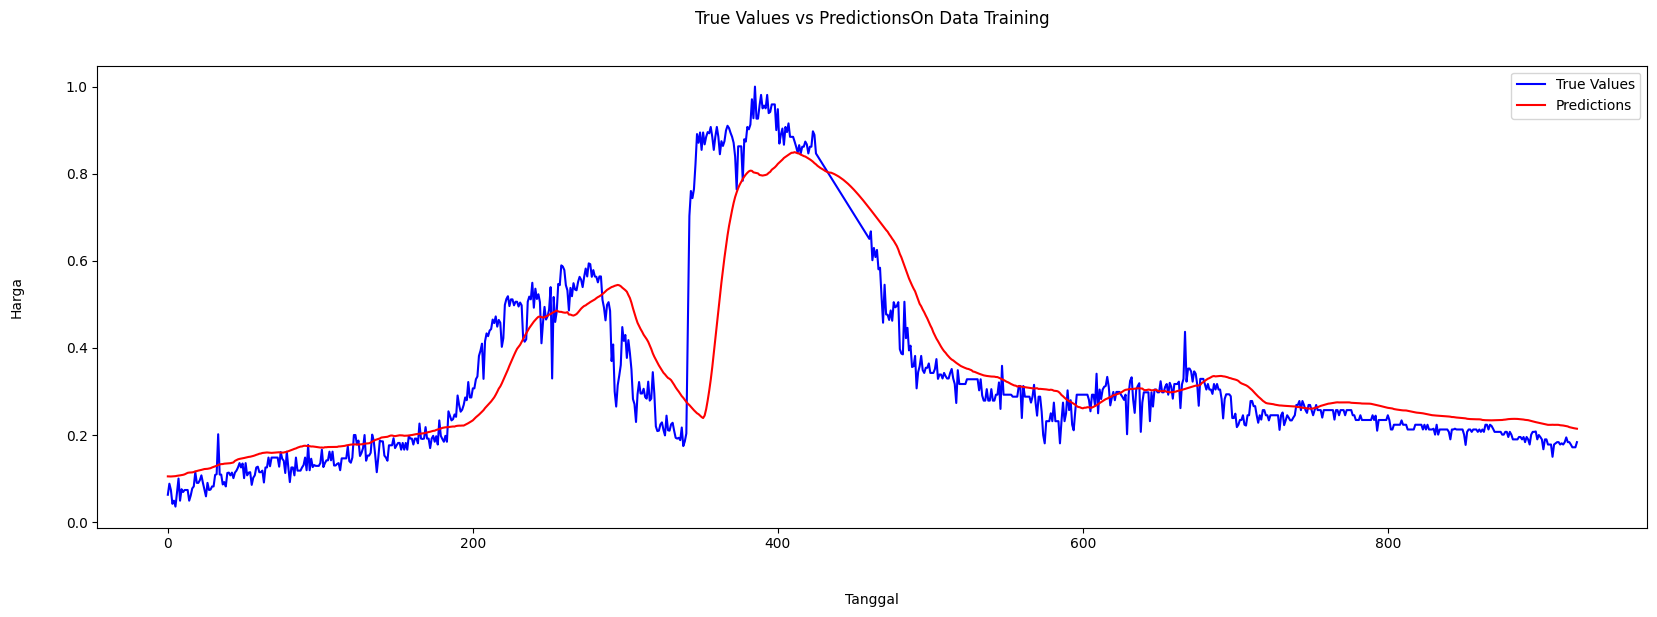

In [28]:
# Plot nilai prediksi dan nilai sebenarnya

plt.figure(figsize=(20, 6))
plt.plot(trainY[:, 10].flatten(), label='True Values', color='blue')
plt.plot(predictionsOnTrain[:,10].flatten(), label='Predictions', color='red')

plt.xlabel('Tanggal', labelpad=30)
plt.ylabel('Harga', labelpad=30)
plt.title('True Values vs PredictionsOn Data Training', pad=30)
plt.legend()

plt.show()

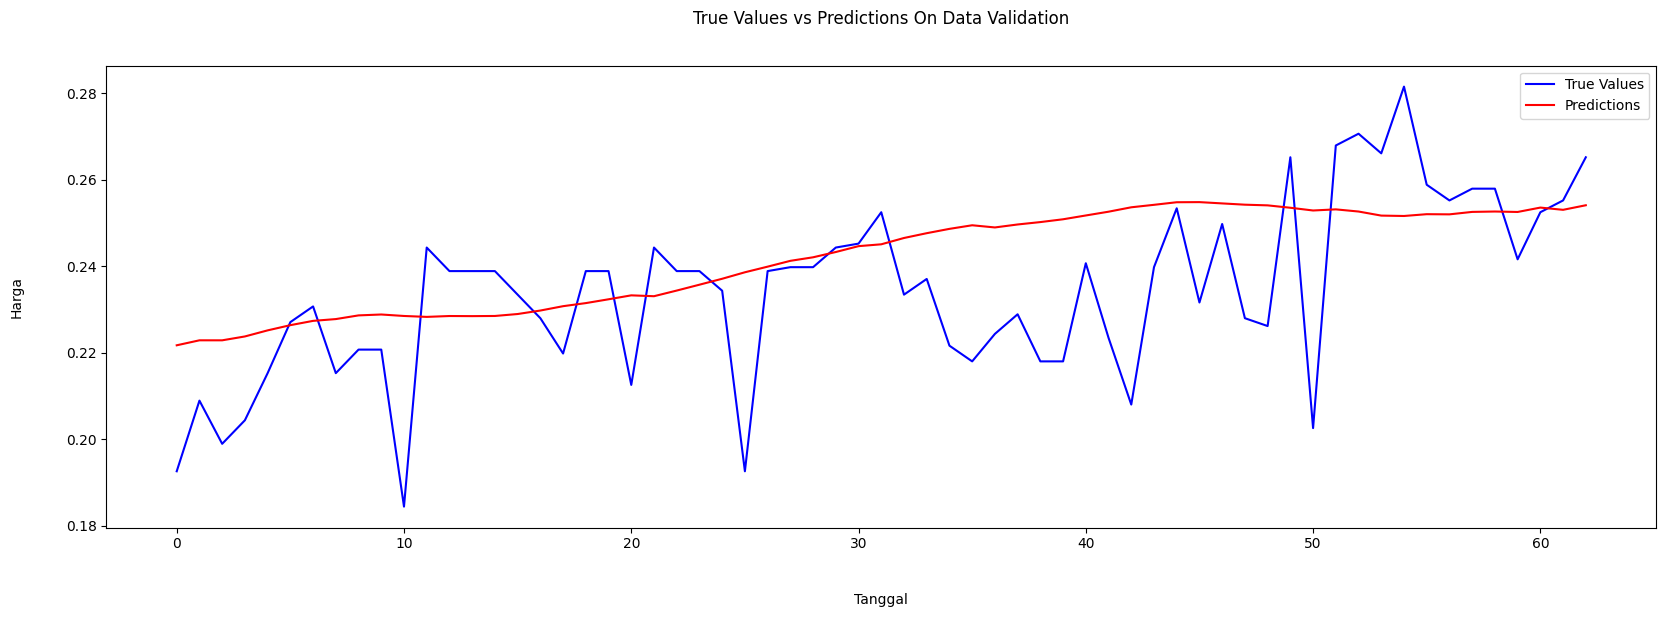

In [29]:
# Plot nilai prediksi dan nilai sebenarnya

plt.figure(figsize=(20, 6))
plt.plot(valY[:, 10].flatten(), label='True Values', color='blue')
plt.plot(predictionsOnVal[:, 10].flatten(), label='Predictions', color='red')

plt.xlabel('Tanggal', labelpad=30)
plt.ylabel('Harga', labelpad=30)
plt.title('True Values vs Predictions On Data Validation', pad=30)
plt.legend()

plt.show()

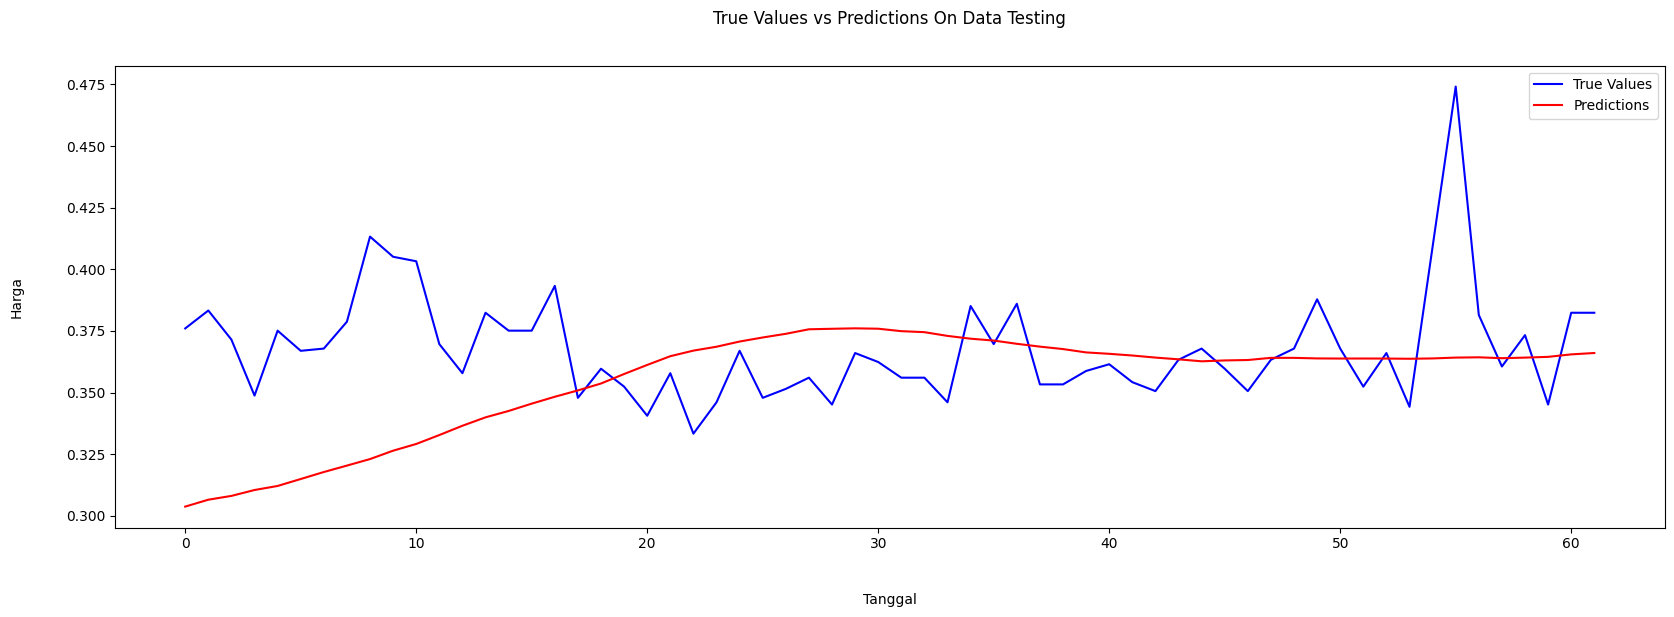

In [31]:
# Plot nilai prediksi dan nilai sebenarnya

plt.figure(figsize=(20, 6))
plt.plot(testY[:, 10].flatten(), label='True Values', color='blue')
plt.plot(predictionsOnTest[:, 10].flatten(), label='Predictions', color='red')

plt.xlabel('Tanggal', labelpad=30)
plt.ylabel('Harga', labelpad=30)
plt.title('True Values vs Predictions On Data Testing', pad=30)
plt.legend()

plt.show()

In [45]:
dataTrainAnn = data_train.reshape((data_train.shape[0], data_train.shape[1]))
dataTestAnn = data_test.reshape((data_test.shape[0], data_test.shape[1]))
dataValAnn = data_val.reshape((data_val.shape[0], data_val.shape[1]))

In [33]:
dataValAnn.shape

(124, 9)

In [47]:
n_output = 31

def createXY_ann(data, n_past, n_feature):
  dataX = []
  dataY = []
  for i in range(n_past, len(data)-31):
    dataX.append(data[i - n_past:i, n_feature])
    dataY.append(data[i:i+n_output, n_feature])
  dataX = np.array(dataX)
  dataY = np.array(dataY)
  return dataX, dataY

trainX_ann, trainY_ann = createXY_ann(dataTrainAnn, 30, 8)
testX_ann, testY_ann = createXY_ann(dataTestAnn, 30, 8)
valX_ann, valY_ann = createXY_ann(dataValAnn, 30, 8)

input_shape_ann = trainX_ann[0].shape
input_shape_ann

(30,)

In [48]:
testY_ann.shape

(62, 31)

In [49]:
# Build the ANN model

model_ann = tf.keras.models.Sequential([
  tf.keras.layers.Input(shape=input_shape_ann),
  tf.keras.layers.Dense(units=64, activation='relu'),
  tf.keras.layers.Dense(units=64, activation='relu'),
  tf.keras.layers.Dense(units=31),
])

model_ann.compile(optimizer='adam', 
                  loss='mean_squared_error')

model_ann.fit(trainX_ann, 
              trainY_ann, 
              epochs=30, 
              batch_size=32, 
              validation_data=(valX_ann, valY_ann))

predictions_ann = model_ann.predict(testX_ann)

mse_ann = np.mean((predictions_ann - testY_ann) ** 2)
print("Loss (ANN):", mse_ann)

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1101 - val_loss: 0.0033
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0185 - val_loss: 5.9907e-04
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0127 - val_loss: 5.7025e-04
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0112 - val_loss: 6.2304e-04
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0112 - val_loss: 4.7900e-04
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0115 - val_loss: 6.9349e-04
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0133 - val_loss: 4.9678e-04
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0108 - val_loss: 6.2487e-04
Epoch 9/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0102 - val_loss: 4.5038e-04
Epoch 10/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0115 - val_loss: 5.2826e-04
Epoch 11/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0129 - val_loss: 5.0378e-04
Epoch 12/30
29/29 ━━━━━━━━━━━━━━━

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Loss (ANN): 0.0012310405977794755


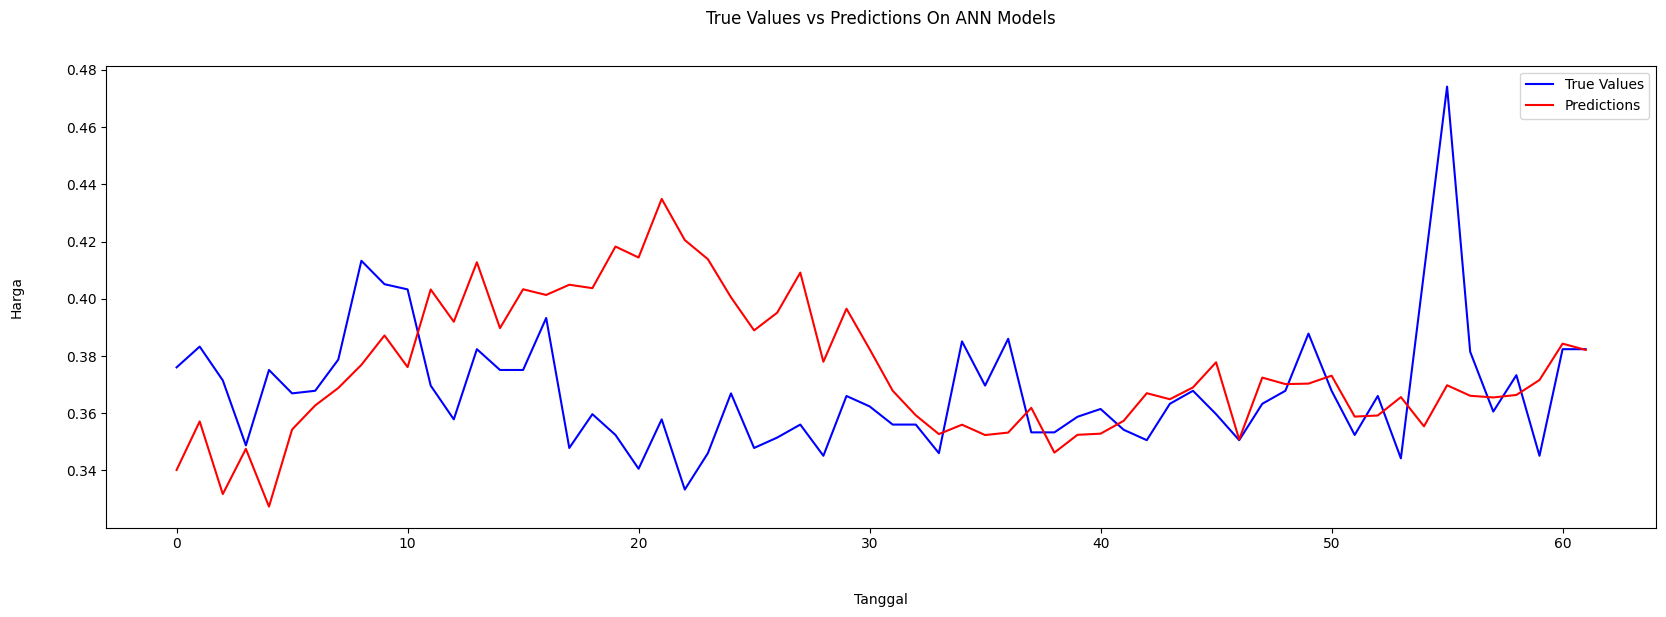

In [51]:
# Plot nilai prediksi dan nilai sebenarnya

plt.figure(figsize=(20, 6))
plt.plot(testY[:, 10], label='True Values', color='blue')
plt.plot(predictions_ann[:, 10], label='Predictions', color='red')

plt.xlabel('Tanggal', labelpad=30)
plt.ylabel('Harga', labelpad=30)
plt.title('True Values vs Predictions On ANN Models', pad=30)
plt.legend()

plt.show()